# Phase 2 — EDA FoodLens
Objectif : comprendre les données, évaluer la pertinence des colonnes, définir les filtres avant import MongoDB.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

CSV_PROPRE = '../data/processed/openfoodfacts_clean.csv'
df = pd.read_csv(CSV_PROPRE, low_memory=False)
print(f'Shape : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')

Shape : 1,373,352 lignes x 22 colonnes


## 1. Taux de NaN par colonne
Décide quelles colonnes sont exploitables.

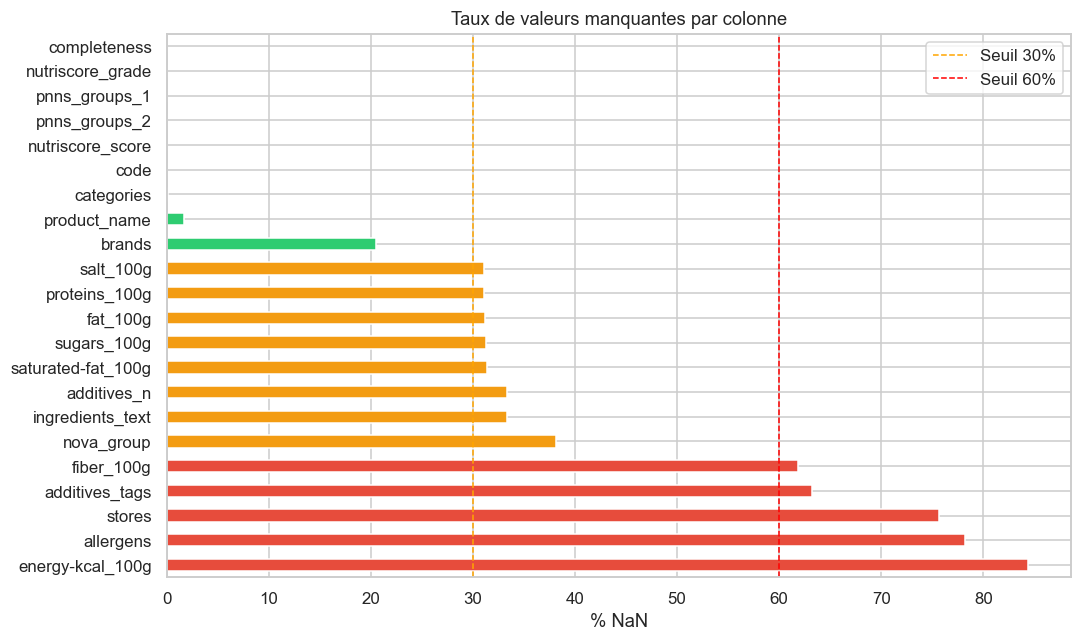

energy-kcal_100g      84.4
allergens             78.2
stores                75.7
additives_tags        63.2
fiber_100g            61.8
nova_group            38.1
ingredients_text      33.3
additives_n           33.3
saturated-fat_100g    31.4
sugars_100g           31.3
fat_100g              31.2
proteins_100g         31.1
salt_100g             31.1
brands                20.5
product_name           1.7
categories             0.1
code                   0.0
nutriscore_score       0.0
pnns_groups_2          0.0
pnns_groups_1          0.0
nutriscore_grade       0.0
completeness           0.0


In [11]:
nan_pct = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 60 else '#f39c12' if v > 30 else '#2ecc71' for v in nan_pct]
nan_pct.plot(kind='barh', ax=ax, color=colors)
ax.axvline(30, color='orange', linestyle='--', linewidth=1, label='Seuil 30%')
ax.axvline(60, color='red', linestyle='--', linewidth=1, label='Seuil 60%')
ax.set_xlabel('% NaN')
ax.set_title('Taux de valeurs manquantes par colonne')
ax.legend()
plt.tight_layout()
plt.show()

print(nan_pct.to_string())

## 2. Distribution Nutri-Score
Colonne centrale pour la substitution et le ML.

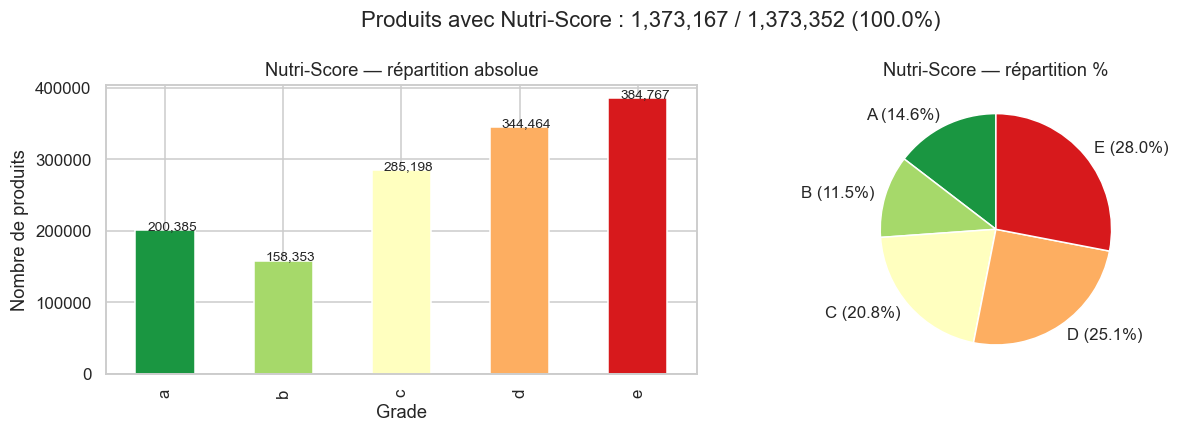

In [12]:
ns = df['nutriscore_grade'].value_counts().reindex(['a','b','c','d','e'])
colors_ns = ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ns.plot(kind='bar', ax=axes[0], color=colors_ns, edgecolor='white')
axes[0].set_title('Nutri-Score — répartition absolue')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Nombre de produits')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+0.1, p.get_height()+500), fontsize=9)

ns_pct = ns / ns.sum() * 100
axes[1].pie(ns_pct, labels=[f'{g.upper()} ({v:.1f}%)' for g,v in zip(ns_pct.index, ns_pct)],
            colors=colors_ns, startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Nutri-Score — répartition %')

plt.suptitle(f"Produits avec Nutri-Score : {ns.sum():,} / {len(df):,} ({ns.sum()/len(df)*100:.1f}%)")
plt.tight_layout()
plt.show()

## 3. Distribution NOVA

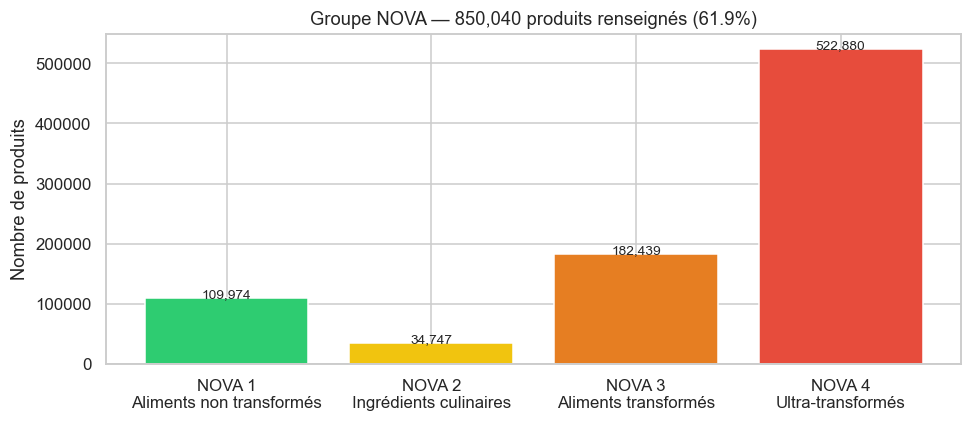

In [13]:
nova = df['nova_group'].value_counts().sort_index()
labels_nova = {
    1: 'NOVA 1\nAliments non transformés',
    2: 'NOVA 2\nIngrédients culinaires',
    3: 'NOVA 3\nAliments transformés',
    4: 'NOVA 4\nUltra-transformés'
}
colors_nova = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar([labels_nova.get(k, str(k)) for k in nova.index], nova.values, color=colors_nova[:len(nova)], edgecolor='white')
for bar, val in zip(bars, nova.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f'{val:,}', ha='center', fontsize=9)
ax.set_title(f"Groupe NOVA — {nova.sum():,} produits renseignés ({nova.sum()/len(df)*100:.1f}%)")
ax.set_ylabel('Nombre de produits')
plt.tight_layout()
plt.show()

## 4. Additifs

Produits avec info additifs : 916,676 (66.7%)
Moyenne : 1.9 | Médiane : 1 | Max : 57


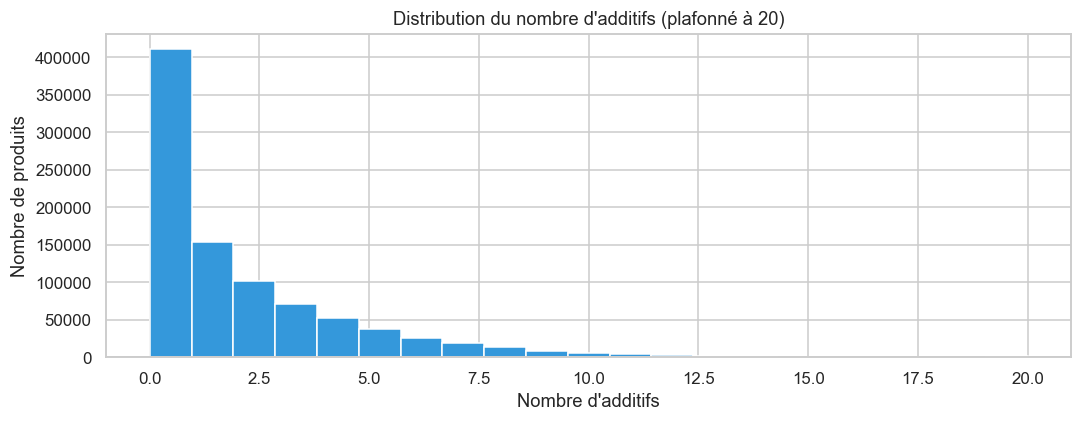

In [14]:
add = df['additives_n'].dropna()
print(f"Produits avec info additifs : {len(add):,} ({len(add)/len(df)*100:.1f}%)")
print(f"Moyenne : {add.mean():.1f} | Médiane : {add.median():.0f} | Max : {add.max():.0f}")

fig, ax = plt.subplots(figsize=(10, 4))
add.clip(upper=20).hist(bins=21, ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Distribution du nombre d\'additifs (plafonné à 20)')
ax.set_xlabel('Nombre d\'additifs')
ax.set_ylabel('Nombre de produits')
plt.tight_layout()
plt.show()

## 5. Couverture des colonnes clés pour l'app

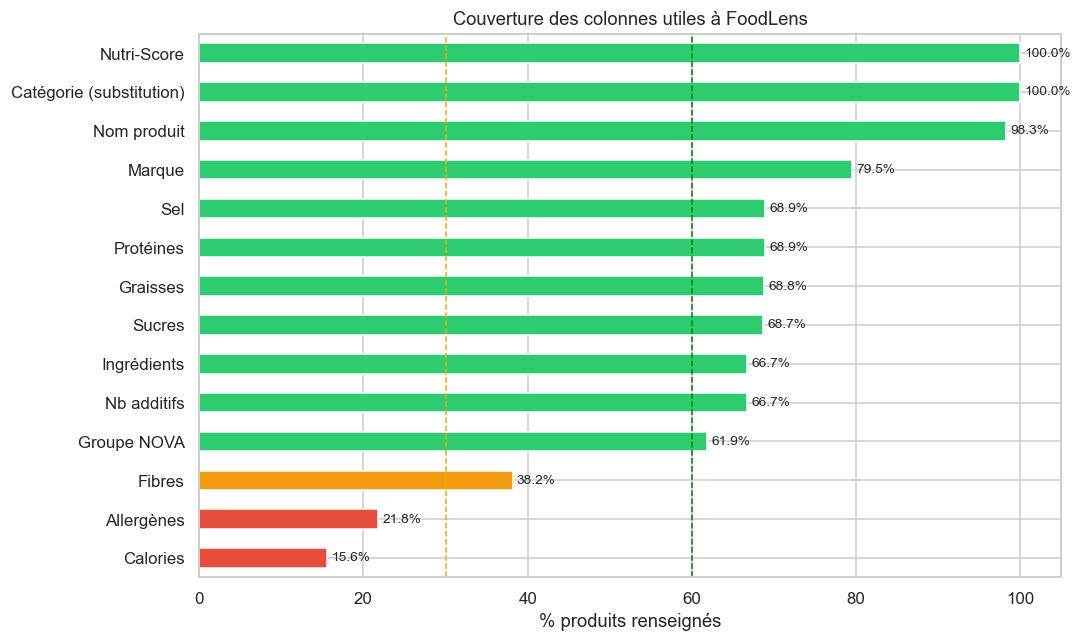

In [15]:
cols_app = {
    'product_name': 'Nom produit',
    'brands': 'Marque',
    'pnns_groups_2': 'Catégorie (substitution)',
    'nutriscore_grade': 'Nutri-Score',
    'nova_group': 'Groupe NOVA',
    'additives_n': 'Nb additifs',
    'energy-kcal_100g': 'Calories',
    'fat_100g': 'Graisses',
    'sugars_100g': 'Sucres',
    'salt_100g': 'Sel',
    'proteins_100g': 'Protéines',
    'fiber_100g': 'Fibres',
    'allergens': 'Allergènes',
    'ingredients_text': 'Ingrédients',
}

couverture = {}
for col, label in cols_app.items():
    if col in df.columns:
        pct = (df[col].notna().sum() / len(df)) * 100
        couverture[label] = round(pct, 1)
    else:
        couverture[label] = 0.0

couv_series = pd.Series(couverture).sort_values()
colors_c = ['#e74c3c' if v < 30 else '#f39c12' if v < 60 else '#2ecc71' for v in couv_series]

fig, ax = plt.subplots(figsize=(10, 6))
couv_series.plot(kind='barh', ax=ax, color=colors_c)
ax.axvline(30, color='orange', linestyle='--', linewidth=1)
ax.axvline(60, color='green', linestyle='--', linewidth=1)
for i, v in enumerate(couv_series):
    ax.text(v+0.5, i, f'{v}%', va='center', fontsize=9)
ax.set_title('Couverture des colonnes utiles à FoodLens')
ax.set_xlabel('% produits renseignés')
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

## 6. Corrélation nutritionnelle vs Nutri-Score

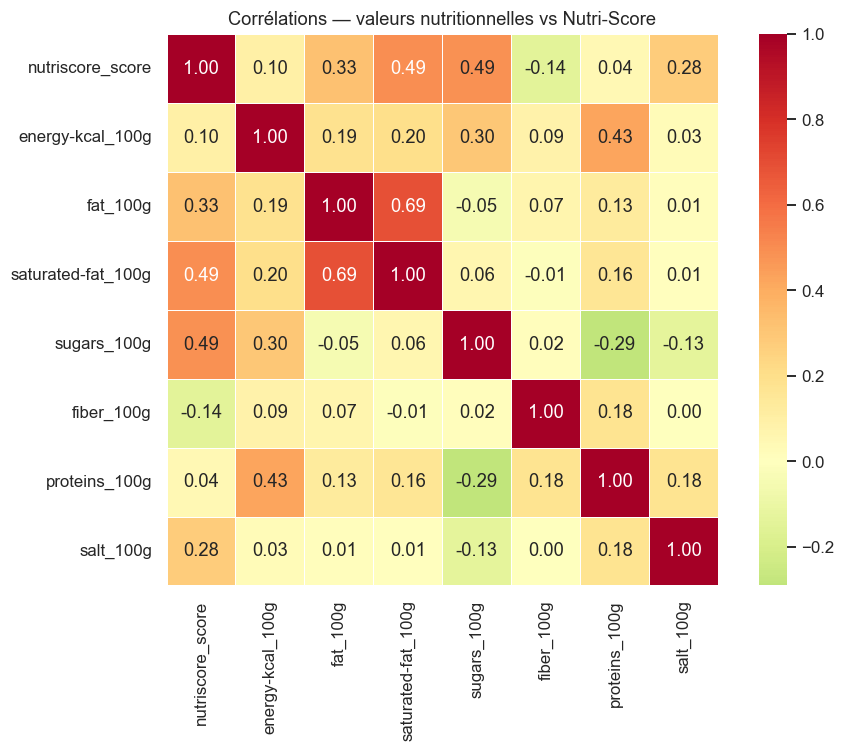

In [16]:
cols_num = ['nutriscore_score','energy-kcal_100g','fat_100g','saturated-fat_100g',
            'sugars_100g','fiber_100g','proteins_100g','salt_100g']
cols_existantes = [c for c in cols_num if c in df.columns]
corr = df[cols_existantes].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Corrélations — valeurs nutritionnelles vs Nutri-Score')
plt.tight_layout()
plt.show()

## 7. Produits utilisables pour la substitution
Un produit est substitutable s'il a : catégorie + nutriscore_grade.

In [17]:
masque_substitution = (
    df['pnns_groups_2'].notna() &
    df['nutriscore_grade'].notna() &
    df['product_name'].notna()
)

masque_ml = (
    df['nutriscore_grade'].notna() &
    df[['energy-kcal_100g','fat_100g','sugars_100g','salt_100g','proteins_100g']].notna().all(axis=1)
)

print(f"Dataset total                          : {len(df):,}")
print(f"Utilisables pour substitution          : {masque_substitution.sum():,} ({masque_substitution.mean()*100:.1f}%)")
print(f"Utilisables pour ML (Nutri-Score pred) : {masque_ml.sum():,} ({masque_ml.mean()*100:.1f}%)")

# Top catégories
print('\nTop 15 catégories (pnns_groups_2) :')
print(df[masque_substitution]['pnns_groups_2'].value_counts().head(15).to_string())

Dataset total                          : 1,373,352
Utilisables pour substitution          : 1,349,850 (98.3%)
Utilisables pour ML (Nutri-Score pred) : 213,175 (15.5%)

Top 15 catégories (pnns_groups_2) :
pnns_groups_2
unknown                 240616
Biscuits and cakes       94991
Sweets                   92271
Dressings and sauces     69821
Cheese                   67239
Cereals                  61993
One-dish meals           61972
Processed meat           60546
Milk and yogurt          49667
Fish and seafood         44303
Meat                     42949
Bread                    39457
Vegetables               38347
Fats                     30179
Appetizers               28387


## 8. Conclusion — Filtres à appliquer avant import MongoDB

In [ ]:
# Filtres retenus après EDA
df_final = df[
    df['product_name'].notna() &
    df['pnns_groups_2'].notna() &
    df['nutriscore_grade'].notna()
].copy()

# Colonnes utiles uniquement
COLS_FINALES = [
    'code', 'product_name', 'brands',
    'pnns_groups_1', 'pnns_groups_2',
    'nutriscore_score', 'nutriscore_grade',
    'nova_group', 'additives_n',
    'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g',
    'ingredients_text', 'allergens'
]
cols_presentes = [c for c in COLS_FINALES if c in df_final.columns]
df_final = df_final[cols_presentes]

print(f"Dataset final pour MongoDB : {len(df_final):,} produits, {df_final.shape[1]} colonnes")
print(f"Réduction vs dataset brut  : {len(df):,} → {len(df_final):,} ({len(df_final)/len(df)*100:.1f}% conservé)")
df_final.head(3)

Dataset final pour MongoDB : 1,349,850 produits, 18 colonnes
Réduction vs dataset brut  : 1,373,352 → 1,349,850 (98.3% conservé)


,code,product_name,brands,pnns_groups_1,pnns_groups_2,nutriscore_score,nutriscore_grade,nova_group,additives_n,energy-kcal_100g,fat_100g,saturated-fat_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,ingredients_text,allergens
0,7,granola Bio le Chocolaté,Mg ricarica,Fruits and vegetables,Dried fruits,4.0,c,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HONIG stillende Frauen nicht geeignet. D bestr...,NaN
2,9,xytitol pastilles,xylimgxyling,Composite foods,Sandwiches,-11.0,a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13,Powdered peanut butter,Pbfit,Composite foods,One-dish meals,3.0,c,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Water, Leptospermum Scoparium Mel (Manuka Hone...",NaN


: 